# IV Surface Reconstruction - Production Colab Notebook

This notebook audits the current PCHIP baseline, validates improved alternatives, and builds the final Kaggle submission.

**Final selected model**: triple-ensemble cross-sectional interpolator
- 45% local quadratic on strike with Gaussian distance weights
- 45% local quadratic on log-moneyness with inverse-distance weights
- 10% PCHIP stabilizer

This design was selected because it beat plain PCHIP in time-aware masked validation and was materially more robust in the final expiry bucket.

## 1. Google Drive mount and environment setup

In [29]:
from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception:
    pass

!pip -q install scipy scikit-learn seaborn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Paths
Set `DATA_PATH` to your dataset location in Google Drive. Outputs are written to `/content/iv_project_output_final`.

In [30]:
from pathlib import Path

DATA_PATH = '/content/drive/MyDrive/Finance OP 26/dataset.csv'  # change if needed
CURRENT_SUBMISSION_PATH = '/content/drive/MyDrive/Finance OP 26/submission.csv'  # optional
OUTDIR = Path('/content/iv_project_output_final')
OUTDIR.mkdir(parents=True, exist_ok=True)

## 3. Imports and helpers

In [31]:
import re
import json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
EXPIRY_TS = pd.Timestamp('2026-01-27 15:30')
MASK_FRAC = 0.18


def parse_metadata(columns):
    pat = re.compile(r'^NIFTY(\d{2}[A-Z]{3}\d{2})(\d+)(CE|PE)$')
    rows = []
    for c in columns:
        if c in {'datetime', 'underlying_price'}:
            continue
        m = pat.match(c)
        if not m:
            raise ValueError(f'Could not parse column: {c}')
        rows.append({
            'contract': c,
            'expiry_code': m.group(1),
            'strike': int(m.group(2)),
            'option_type': m.group(3),
        })
    return pd.DataFrame(rows).sort_values(['option_type', 'strike']).reset_index(drop=True)


def load_dataset(path):
    df = pd.read_csv(path)
    df['dt'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')
    df = df.sort_values('dt').reset_index(drop=True)
    df['days_to_expiry'] = ((EXPIRY_TS - df['dt']).dt.total_seconds() / (24 * 3600)).clip(lower=0)
    option_cols = [c for c in df.columns if c not in ['datetime', 'underlying_price', 'dt', 'days_to_expiry']]
    meta = parse_metadata(option_cols)
    return df, meta, option_cols


def pchip_predict(x, y, x0):
    mask = ~np.isnan(y)
    x = np.asarray(x, dtype=float)[mask]
    y = np.asarray(y, dtype=float)[mask]
    if len(y) == 0:
        return np.nan
    if len(y) == 1:
        return float(y[0])
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    try:
        pred = float(PchipInterpolator(x, y, extrapolate=True)(x0))
    except Exception:
        pred = float(np.interp(x0, x, y))
    if not np.isfinite(pred):
        pred = float(np.interp(x0, x, y))
    return pred


def local_poly_predict(x, y, x0, k=5, deg=2, weight='gauss'):
    mask = ~np.isnan(y)
    x = np.asarray(x, dtype=float)[mask]
    y = np.asarray(y, dtype=float)[mask]
    if len(y) == 0:
        return np.nan
    if len(y) == 1:
        return float(y[0])

    idx = np.argsort(np.abs(x - x0))[:min(k, len(x))]
    xs = x[idx]
    ys = y[idx]
    order = np.argsort(xs)
    xs = xs[order]
    ys = ys[order]

    deg = min(deg, len(xs) - 1)
    d = np.abs(xs - x0)
    if weight == 'gauss':
        nonzero = d[d > 0]
        bw = np.median(nonzero) if len(nonzero) else 1.0
        bw = max(bw, 1.0)
        w = np.exp(-0.5 * (d / bw) ** 2)
    elif weight == 'inv':
        w = 1.0 / np.maximum(d, 1e-6)
    elif weight == 'inv2':
        w = 1.0 / np.maximum(d, 1e-6) ** 2
    else:
        w = None

    try:
        coef = np.polyfit(xs, ys, deg=deg, w=w)
        pred = float(np.polyval(coef, x0))
    except Exception:
        pred = float(np.interp(x0, xs, ys))

    if not np.isfinite(pred):
        pred = float(np.interp(x0, xs, ys))
    return pred


def triple_ensemble_row_predict(strikes, row_values, underlying_price, target_idx):
    x_strike = strikes
    x_logm = np.log(strikes / underlying_price)
    p_gauss = local_poly_predict(x_strike, row_values, x_strike[target_idx], k=5, deg=2, weight='gauss')
    p_logm = local_poly_predict(x_logm, row_values, x_logm[target_idx], k=5, deg=2, weight='inv')
    p_pchip = pchip_predict(x_strike, row_values, x_strike[target_idx])

    preds = np.array([p_gauss, p_logm, p_pchip], dtype=float)
    finite = np.isfinite(preds)
    if finite.sum() == 0:
        finite_vals = np.asarray(row_values, dtype=float)[~np.isnan(row_values)]
        return float(np.nanmean(finite_vals)) if len(finite_vals) else 0.15
    if finite.sum() < 3:
        return float(np.nanmean(preds[finite]))

    pred = 0.45 * p_gauss + 0.45 * p_logm + 0.10 * p_pchip
    return float(max(pred, 1e-6))


def fill_surface(df, meta, option_cols):
    filled = df.copy()
    cols_by_type = {t: meta.loc[meta['option_type'] == t, 'contract'].tolist() for t in ['CE', 'PE']}
    strikes_by_type = {t: meta.loc[meta['option_type'] == t, 'strike'].to_numpy(dtype=float) for t in ['CE', 'PE']}

    prediction_rows = []
    for opt_type in ['CE', 'PE']:
        cols = cols_by_type[opt_type]
        strikes = strikes_by_type[opt_type]
        arr = filled[cols].to_numpy(dtype=float)
        underlying = filled['underlying_price'].to_numpy(dtype=float)
        for i in range(len(filled)):
            row = arr[i].copy()
            for j, col in enumerate(cols):
                if np.isnan(row[j]):
                    pred = triple_ensemble_row_predict(strikes, row, underlying[i], j)
                    arr[i, j] = pred
                    prediction_rows.append({
                        'datetime': filled.at[i, 'datetime'],
                        'contract': col,
                        'prediction': pred,
                        'option_type': opt_type,
                        'strike': int(strikes[j]),
                        'underlying_price': float(underlying[i]),
                        'days_to_expiry': float(filled.at[i, 'days_to_expiry']),
                    })
        filled.loc[:, cols] = arr
    return filled, pd.DataFrame(prediction_rows)


def make_mask(df, option_cols, val_idx, frac=MASK_FRAC, seed=SEED):
    rng = np.random.default_rng(seed)
    mask = pd.DataFrame(False, index=df.index, columns=option_cols)
    for c in option_cols:
        observed = [i for i in val_idx if pd.notna(df.at[i, c])]
        if not observed:
            continue
        k = max(1, int(np.ceil(len(observed) * frac)))
        chosen = rng.choice(observed, size=k, replace=False)
        mask.loc[chosen, c] = True
    return mask


def evaluate_methods(df, meta, option_cols):
    cols_by_type = {t: meta.loc[meta['option_type'] == t, 'contract'].tolist() for t in ['CE', 'PE']}
    strikes_by_type = {t: meta.loc[meta['option_type'] == t, 'strike'].to_numpy(dtype=float) for t in ['CE', 'PE']}

    def predict_from_masked(masked_df, model_name):
        pred = masked_df[option_cols].copy()
        for opt_type in ['CE', 'PE']:
            cols = cols_by_type[opt_type]
            strikes = strikes_by_type[opt_type]
            arr = masked_df[cols].to_numpy(dtype=float)
            underlying = masked_df['underlying_price'].to_numpy(dtype=float)
            for i in range(len(masked_df)):
                row = arr[i].copy()
                x_strike = strikes
                x_logm = np.log(strikes / underlying[i])
                for j, c in enumerate(cols):
                    if np.isnan(row[j]):
                        if model_name == 'pchip':
                            val = pchip_predict(x_strike, row, x_strike[j])
                        elif model_name == 'local_poly_gauss':
                            val = local_poly_predict(x_strike, row, x_strike[j], k=5, deg=2, weight='gauss')
                        elif model_name == 'local_poly_logm':
                            val = local_poly_predict(x_logm, row, x_logm[j], k=5, deg=2, weight='inv')
                        elif model_name == 'triple_ensemble':
                            val = triple_ensemble_row_predict(strikes, row, underlying[i], j)
                        else:
                            raise ValueError(model_name)
                        pred.at[i, c] = max(float(val), 1e-6)
        return pred

    fold_rows = []
    detail_rows = []
    splitter = TimeSeriesSplit(n_splits=4)
    for fold, (_, val_idx) in enumerate(splitter.split(df), start=1):
        val_idx = list(val_idx)
        art_mask = make_mask(df, option_cols, val_idx, seed=100 + fold)
        masked_df = df.copy()
        for c in option_cols:
            idxs = art_mask.index[art_mask[c]].tolist()
            if idxs:
                masked_df.loc[idxs, c] = np.nan
        eval_pairs = [(i, c, float(df.at[i, c])) for c in option_cols for i in art_mask.index[art_mask[c]].tolist()]

        for model_name in ['pchip', 'local_poly_gauss', 'local_poly_logm', 'triple_ensemble']:
            pred_df = predict_from_masked(masked_df, model_name)
            y_true = []
            y_pred = []
            for i, c, y in eval_pairs:
                p = float(pred_df.at[i, c])
                y_true.append(y)
                y_pred.append(p)
                detail_rows.append({
                    'fold': fold,
                    'model': model_name,
                    'datetime': df.at[i, 'datetime'],
                    'contract': c,
                    'days_to_expiry': float(df.at[i, 'days_to_expiry']),
                    'squared_error': (p - y) ** 2,
                    'abs_error': abs(p - y),
                })
            mse = mean_squared_error(y_true, y_pred)
            mae = mean_absolute_error(y_true, y_pred)
            rmse = mse ** 0.5
            fold_rows.append({'fold': fold, 'model': model_name, 'mse': mse, 'mae': mae, 'rmse': rmse})

    fold_df = pd.DataFrame(fold_rows)
    summary = fold_df.groupby('model')[['mse', 'mae', 'rmse']].agg(['mean', 'std']).reset_index()
    summary.columns = ['model', 'mse_mean', 'mse_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std']
    return fold_df, summary.sort_values('mse_mean'), pd.DataFrame(detail_rows)


def make_submission(original_df, filled_df, option_cols, output_path):
    rows = []
    for c in option_cols:
        missing_idx = original_df.index[original_df[c].isna()].tolist()
        for i in missing_idx:
            rows.append({'id': f"{original_df.at[i, 'datetime']}||{c}", 'value': filled_df.at[i, c]})
    sub = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
    sub.to_csv(output_path, index=False)
    return sub


def compare_with_current(new_sub_path, current_sub_path):
    if not Path(current_sub_path).exists():
        return {}
    new_sub = pd.read_csv(new_sub_path)
    cur_sub = pd.read_csv(current_sub_path)
    m = new_sub.merge(cur_sub, on='id', suffixes=('_new', '_current'))
    diff = (m['value_new'] - m['value_current']).abs()
    return {
        'overlap_rows': int(len(m)),
        'mean_abs_diff_vs_current_submission': float(diff.mean()),
        'median_abs_diff_vs_current_submission': float(diff.median()),
        'max_abs_diff_vs_current_submission': float(diff.max()),
    }


def pca_diagnostics(df, option_cols):
    X = df[option_cols].copy()
    X = X.fillna(X.mean())
    X = (X - X.mean()) / X.std(ddof=0)
    _, s, _ = np.linalg.svd(X.to_numpy(), full_matrices=False)
    var = (s ** 2) / np.sum(s ** 2)
    return {
        'pc1': float(var[0]),
        'pc2_cum': float(var[:2].sum()),
        'pc3_cum': float(var[:3].sum()),
        'pc5_cum': float(var[:5].sum()),
        'pc8_cum': float(var[:8].sum()),
        'pc10_cum': float(var[:10].sum()),
    }


def main():
    outdir = Path('final_outputs')
    outdir.mkdir(exist_ok=True)

    df, meta, option_cols = load_dataset(DATA_PATH)
    fold_df, summary_df, detail_df = evaluate_methods(df, meta, option_cols)
    filled_df, pred_df = fill_surface(df, meta, option_cols)

    filled_export = filled_df.drop(columns=['dt', 'days_to_expiry'])
    filled_path = outdir / 'filled_dataset_best.csv'
    filled_export.to_csv(filled_path, index=False)

    submission_path = outdir / 'submission_best.csv'
    sub_df = make_submission(df, filled_df, option_cols, submission_path)

    detail_df['expiry_bucket'] = pd.cut(detail_df['days_to_expiry'], bins=[-1, 1, 3, 7, 30], labels=['<=1d', '1-3d', '3-7d', '>7d'])
    expiry_mse = detail_df.groupby(['model', 'expiry_bucket'], observed=False)['squared_error'].mean().unstack(1)

    report = {
        'dataset_shape': {'rows': int(df.shape[0]), 'columns': int(df.shape[1] - 2)},
        'missing_values': int(df[option_cols].isna().sum().sum()),
        'contracts': int(len(option_cols)),
        'pca_diagnostics': pca_diagnostics(df, option_cols),
        'validation_summary': summary_df.to_dict(orient='records'),
        'expiry_bucket_mse': expiry_mse.reset_index().to_dict(orient='records'),
        'prediction_stats': {
            'submission_rows': int(len(sub_df)),
            'prediction_min': float(pred_df['prediction'].min()),
            'prediction_median': float(pred_df['prediction'].median()),
            'prediction_max': float(pred_df['prediction'].max()),
        },
        'comparison_vs_current_submission': compare_with_current(submission_path, 'submission.csv'),
    }

    fold_df.to_csv(outdir / 'validation_folds.csv', index=False)
    summary_df.to_csv(outdir / 'validation_summary.csv', index=False)
    detail_df.to_csv(outdir / 'validation_details.csv', index=False)
    pred_df.to_csv(outdir / 'missing_predictions_best.csv', index=False)
    with open(outdir / 'research_summary.json', 'w') as f:
        json.dump(report, f, indent=2)

    print(json.dumps(report, indent=2))
    print(f'Wrote: {filled_path}')
    print(f'Wrote: {submission_path}')


if __name__ == '__main__':
    main()

{
  "dataset_shape": {
    "rows": 975,
    "columns": 30
  },
  "missing_values": 5460,
  "contracts": 28,
  "pca_diagnostics": {
    "pc1": 0.7361634265941192,
    "pc2_cum": 0.8126917952554664,
    "pc3_cum": 0.8440410248137723,
    "pc5_cum": 0.8853302615964969,
    "pc8_cum": 0.9234880052003706,
    "pc10_cum": 0.9394141441523288
  },
  "validation_summary": [
    {
      "model": "triple_ensemble",
      "mse_mean": 9.926891835646317e-05,
      "mse_std": 0.0001891411014350497,
      "mae_mean": 0.0022301242188272705,
      "mae_std": 0.002818211752884357,
      "rmse_mean": 0.00640369905316104,
      "rmse_std": 0.008813743570357043
    },
    {
      "model": "local_poly_gauss",
      "mse_mean": 0.00010151584625613696,
      "mse_std": 0.0001937113549355334,
      "mae_mean": 0.0022700005503251603,
      "mae_std": 0.0028987420578036587,
      "rmse_mean": 0.006457435446798805,
      "rmse_std": 0.008930649375908659
    },
    {
      "model": "local_poly_logm",
      "mse_mea

## 4. Load dataset

In [32]:
df, meta, option_cols = load_dataset(DATA_PATH)
print(df.shape)
print(meta.head())
print('Missing option values:', int(df[option_cols].isna().sum().sum()))
df.head()

(975, 32)
              contract expiry_code  strike option_type
0  NIFTY27JAN2625200CE     27JAN26   25200          CE
1  NIFTY27JAN2625300CE     27JAN26   25300          CE
2  NIFTY27JAN2625400CE     27JAN26   25400          CE
3  NIFTY27JAN2625500CE     27JAN26   25500          CE
4  NIFTY27JAN2625600CE     27JAN26   25600          CE
Missing option values: 5460


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE,dt,days_to_expiry
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150,2026-01-07 09:15:00,20.260417
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353,2026-01-07 09:20:00,20.256944
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN,2026-01-07 09:25:00,20.253472
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,...,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200,2026-01-07 09:30:00,20.250000
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,...,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN,2026-01-07 09:35:00,20.246528


## 5. Quick EDA

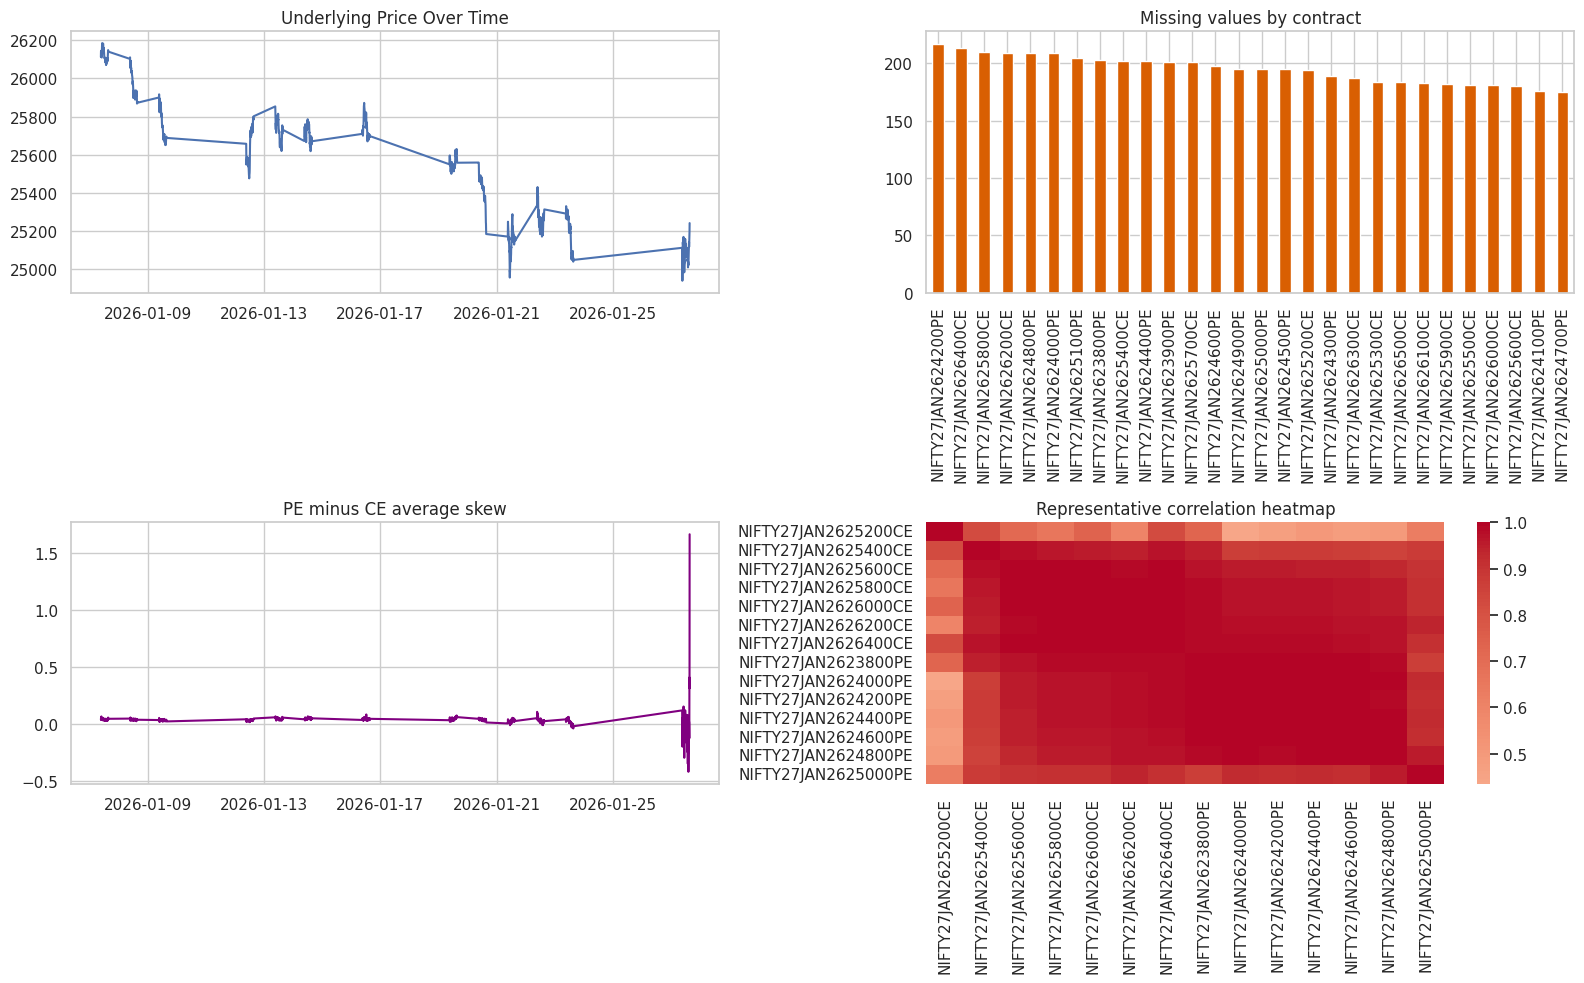

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

ce_cols = meta.loc[meta.option_type == 'CE', 'contract'].tolist()
pe_cols = meta.loc[meta.option_type == 'PE', 'contract'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(df['dt'], df['underlying_price'])
axes[0,0].set_title('Underlying Price Over Time')

miss_by_contract = df[option_cols].isna().sum().sort_values(ascending=False)
miss_by_contract.plot(kind='bar', ax=axes[0,1], color='#d95f02')
axes[0,1].set_title('Missing values by contract')
axes[0,1].tick_params(axis='x', rotation=90)

axes[1,0].plot(df['dt'], df[pe_cols].mean(axis=1) - df[ce_cols].mean(axis=1), color='purple')
axes[1,0].set_title('PE minus CE average skew')

subset = meta.groupby('option_type').apply(lambda x: x.iloc[::2], include_groups=False).reset_index(drop=True)['contract'].tolist()
sns.heatmap(df[subset].corr(), cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Representative correlation heatmap')

plt.tight_layout()
plt.show()

## 6. Validation framework
TimeSeriesSplit is used. In each validation fold, a fresh random mask is applied only to observed values in the validation segment. No future values are used to construct predictions.

In [34]:
fold_df, summary_df, detail_df = evaluate_methods(df, meta, option_cols)
summary_df

,model,mse_mean,mse_std,mae_mean,mae_std,rmse_mean,rmse_std
3,triple_ensemble,0.000099,0.000189,0.002230,0.002818,0.006404,0.008814
0,local_poly_gauss,0.000102,0.000194,0.002270,0.002899,0.006457,0.008931
1,local_poly_logm,0.000102,0.000195,0.002267,0.002894,0.006468,0.008951
2,pchip,0.000169,0.000315,0.002626,0.003142,0.008705,0.011168


## 7. Expiry bucket analysis

In [35]:
detail_df['expiry_bucket'] = pd.cut(detail_df['days_to_expiry'], bins=[-1, 1, 3, 7, 30], labels=['<=1d', '1-3d', '3-7d', '>7d'])
expiry_bucket_mse = detail_df.groupby(['model', 'expiry_bucket'], observed=False)['squared_error'].mean().unstack(1)
expiry_bucket_mse

expiry_bucket,<=1d,1-3d,3-7d,>7d
model,,,,
local_poly_gauss,0.000986,NaN,0.000003,0.000006
local_poly_logm,0.000991,NaN,0.000003,0.000006
pchip,0.001618,NaN,0.000004,0.000014
triple_ensemble,0.000964,NaN,0.000003,0.000006


## 8. Low-rank / factor diagnostics

In [36]:
pca_diagnostics(df, option_cols)

{'pc1': 0.7361634265941192,
 'pc2_cum': 0.8126917952554664,
 'pc3_cum': 0.8440410248137723,
 'pc5_cum': 0.8853302615964969,
 'pc8_cum': 0.9234880052003706,
 'pc10_cum': 0.9394141441523288}

## 9. Fit final model on full dataset and generate deliverables

In [37]:
filled_df, pred_df = fill_surface(df, meta, option_cols)
filled_export = filled_df.drop(columns=['dt', 'days_to_expiry'])
filled_path = OUTDIR / 'filled_dataset_best.csv'
filled_export.to_csv(filled_path, index=False)
submission_path = OUTDIR / 'submission_best.csv'
submission_df = make_submission(df, filled_df, option_cols, submission_path)
print(filled_path)
print(submission_path)
submission_df.head()

/content/iv_project_output_final/filled_dataset_best.csv
/content/iv_project_output_final/submission_best.csv


,id,value
0,07-01-2026 09:15||NIFTY27JAN2624100PE,0.163572
1,07-01-2026 09:15||NIFTY27JAN2625500CE,0.113625
2,07-01-2026 09:15||NIFTY27JAN2625800CE,0.100991
3,07-01-2026 09:20||NIFTY27JAN2624000PE,0.170254
4,07-01-2026 09:20||NIFTY27JAN2624200PE,0.159879


## 10. Optional comparison with current submission

In [38]:
from pathlib import Path
if Path(CURRENT_SUBMISSION_PATH).exists():
    compare_with_current(submission_path, CURRENT_SUBMISSION_PATH)
else:
    print('CURRENT_SUBMISSION_PATH not found; skipping comparison.')

## 11. Save validation outputs

In [39]:
fold_df.to_csv(OUTDIR / 'validation_folds.csv', index=False)
summary_df.to_csv(OUTDIR / 'validation_summary.csv', index=False)
detail_df.to_csv(OUTDIR / 'validation_details.csv', index=False)
pred_df.to_csv(OUTDIR / 'missing_predictions_best.csv', index=False)
print('All outputs saved to', OUTDIR)

All outputs saved to /content/iv_project_output_final
